# UJI KEKEKALAN MATERI DAN UJI LOOP UMPAN BALIK

Dua uji struktur pelengkap mengikuti Mai & Smith (2018).

**1. Uji kekekalan materi.** Memeriksa bahwa tidak ada materi yang hilang atau muncul di luar
aliran yang didefinisikan. Dengan metode Euler dan TIME STEP 1:

> Stok(t+1) = Stok(t) + Σ inflow(t) − Σ outflow(t)

Diperiksa untuk kelima stok sepanjang 2025–2049.

**2. Uji loop umpan balik.** Tiap loop dilumpuhkan dengan menahan variabel yang menutup loop
pada nilai tahun dasar (*loop knockout*), lalu dampaknya terhadap perilaku 2050 dibandingkan BASE.
Cara ini tidak mengubah struktur model, hanya mengganti satu variabel menjadi konstanta saat run.

**File:** `MODEL_SISTEM_DINAMIS.mdl` versi final — LPE 0,27726; LPD 0,207945; TPK Ambang 0,275;
Laju Demolisi 0,05; Sensitivitas Konstruksi 2,31385; Laju Konversi Dasar 0,0436052.

In [1]:
!pip install pysd openpyxl matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 23.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[01] Uji Struktural/Uji Kekekalan Materi dan Uji Loop")
FILE = FOLDER / "MODEL SISTEM DINAMIS.mdl"

model = pysd.read_vensim(str(FILE))
NAMA_TPK  = [k for k in model.namespace if "TPK" in k and "Ambang" not in k][0]
NAMA_ODTW = [k for k in model.namespace if "Pembangunan" in k and "ODTW" in k][0]

VARIABEL = ["Jumlah Wisatawan", "Laju Kedatangan Wisatawan", "Laju Penurunan Wisatawan",
            "Jumlah Hotel dan Akomodasi", "Laju Konstruksi Hotel dan Akomodasi", "Laju Demolisi Hotel dan Akomodasi",
            "Jumlah Objek Daya Tarik Wisata", NAMA_ODTW, "Laju Penutupan ODTW",
            "Tenaga Kerja Pariwisata", "Laju Penyerapan Tenaga Kerja Pariwisata", "Laju Keluar Tenaga Kerja Pariwisata",
            "Lahan Terbangun", "Laju Konversi Lahan Pariwisata", "Laju Konversi Lahan Non Pariwisata",
            "Daya Tarik Destinasi Wisata", "Kepadatan Wisatawan", "Rasio Daya Dukung Lahan", NAMA_TPK]

def jalankan(params=None):
    m = pysd.read_vensim(str(FILE))
    r = m.run(params=params or {}, return_columns=VARIABEL, return_timestamps=list(range(2025, 2051)))
    r = r.apply(lambda s: np.real(s.astype(complex)))
    r.columns = [c.strip('"') for c in r.columns]
    return r

BASE = jalankan()
print("Cek JW 2026:", f"{BASE['Jumlah Wisatawan'][2026]:,.0f}", "(harus 43.516.522)")

Cek JW 2026: 43,516,522 (harus 43.516.522)


## 1. Uji kekekalan materi

In [9]:
STOK = {
 "Jumlah Wisatawan":              (["Laju Kedatangan Wisatawan"],            ["Laju Penurunan Wisatawan"]),
 "Jumlah Hotel dan Akomodasi":    (["Laju Konstruksi Hotel dan Akomodasi"],  ["Laju Demolisi Hotel dan Akomodasi"]),
 "Jumlah Objek Daya Tarik Wisata":(["Laju Pembangunan/Penambahan ODTW"], ["Laju Penutupan ODTW"]),
 "Tenaga Kerja Pariwisata":       (["Laju Penyerapan Tenaga Kerja Pariwisata"], ["Laju Keluar Tenaga Kerja Pariwisata"]),
 "Lahan Terbangun":               (["Laju Konversi Lahan Pariwisata", "Laju Konversi Lahan Non Pariwisata"], []),
}

rows = []
for s, (inflow, outflow) in STOK.items():
    selisih = []
    for t in range(2025, 2050):
        pred = BASE[s][t] + sum(BASE[i][t] for i in inflow) - sum(BASE[o][t] for o in outflow)
        selisih.append(pred - BASE[s][t+1])
    selisih = np.array(selisih)
    rel = np.max(np.abs(selisih)) / BASE[s].mean()
    rows.append({"Stok":s,
                 "Inflow":" + ".join(inflow), "Outflow":" + ".join(outflow) if outflow else "(tidak ada)",
                 "Stok 2025":BASE[s][2025],
                 "Prediksi 2026":BASE[s][2025] + sum(BASE[i][2025] for i in inflow) - sum(BASE[o][2025] for o in outflow),
                 "Simulasi 2026":BASE[s][2026],
                 "Selisih maksimum 2025-2049":np.max(np.abs(selisih)),
                 "Selisih relatif":rel,
                 "Status":"Kekal" if rel < 1e-9 else "PERIKSA"})

kekekalan = pd.DataFrame(rows)
display(kekekalan.round(6))

print("Contoh rinci Hotel 2025 -> 2026:")
print(f"  {BASE['Jumlah Hotel dan Akomodasi'][2025]:,.0f}"
      f" + {BASE['Laju Konstruksi Hotel dan Akomodasi'][2025]:.5f}"
      f" - {BASE['Laju Demolisi Hotel dan Akomodasi'][2025]:.5f}"
      f" = {BASE['Jumlah Hotel dan Akomodasi'][2025]+BASE['Laju Konstruksi Hotel dan Akomodasi'][2025]-BASE['Laju Demolisi Hotel dan Akomodasi'][2025]:.5f}"
      f"   | simulasi 2026 = {BASE['Jumlah Hotel dan Akomodasi'][2026]:.5f}")

,Stok,Inflow,Outflow,Stok 2025,Prediksi 2026,Simulasi 2026,Selisih maksimum 2025-2049,Selisih relatif,Status
0,Jumlah Wisatawan,Laju Kedatangan Wisatawan,Laju Penurunan Wisatawan,40695700.0,4.351652e+07,4.351652e+07,0.0,0.0,Kekal
1,Jumlah Hotel dan Akomodasi,Laju Konstruksi Hotel dan Akomodasi,Laju Demolisi Hotel dan Akomodasi,2291.0,2.334629e+03,2.334629e+03,0.0,0.0,Kekal
2,Jumlah Objek Daya Tarik Wisata,Laju Pembangunan/Penambahan ODTW,Laju Penutupan ODTW,201.0,2.050941e+02,2.050941e+02,0.0,0.0,Kekal
3,Tenaga Kerja Pariwisata,Laju Penyerapan Tenaga Kerja Pariwisata,Laju Keluar Tenaga Kerja Pariwisata,364994.0,3.649945e+05,3.649945e+05,0.0,0.0,Kekal
4,Lahan Terbangun,Laju Konversi Lahan Pariwisata + Laju Konversi...,(tidak ada),55029.5,5.703545e+04,5.703545e+04,0.0,0.0,Kekal


Contoh rinci Hotel 2025 -> 2026:
  2,291 + 158.17937 - 114.55000 = 2334.62937   | simulasi 2026 = 2334.62937


## 2. Uji loop umpan balik

Tiap loop dilumpuhkan dengan menahan variabel penutupnya pada nilai 2025:

| Loop | Variabel ditahan | Alasan |
|---|---|---|
| B1 kepadatan | Kepadatan Wisatawan | memutus Wisatawan → Kepadatan → Daya Tarik |
| B2 daya dukung lahan | Rasio Daya Dukung Lahan | memutus Lahan → RDDL → Daya Tarik dan konversi |
| R2 ekonomi–atraksi | Jumlah ODTW | memutus Investasi → ODTW → Daya Tarik |
| B okupansi hotel | Rasio Permintaan | memutus Hotel → Rasio Permintaan → Konstruksi |
| B goal-seeking TK | Tenaga Kerja Dibutuhkan | memutus selisih kebutuhan → penyerapan |
| R1 murni | Daya Tarik = 1 | seluruh rem dimatikan sekaligus |

In [10]:
KNOCKOUT = {
 "B1 kepadatan":              {"Kepadatan Wisatawan": float(BASE["Kepadatan Wisatawan"][2025])},
 "B2 daya dukung lahan":      {"Rasio Daya Dukung Lahan": float(BASE["Rasio Daya Dukung Lahan"][2025])},
 "R2 ekonomi-atraksi":        {"Jumlah Objek Daya Tarik Wisata": float(BASE["Jumlah Objek Daya Tarik Wisata"][2025])},
 "B okupansi hotel":          {"Rasio Permintaan terhadap Kapasitas Kamar": float(BASE[NAMA_TPK.strip('"')][2025])},
 "B goal-seeking TK":         {"Tenaga Kerja Dibutuhkan": float(BASE["Tenaga Kerja Pariwisata"][2025])},
 "Semua rem mati (R1 murni)": {"Daya Tarik Destinasi Wisata": 1.0},
}

def ringkas(nama, r, base_jw):
    return {"Kondisi":nama, "JW 2050 (juta)":r["Jumlah Wisatawan"][2050]/1e6,
            "Hotel 2050":r["Jumlah Hotel dan Akomodasi"][2050],
            "ODTW 2050":r["Jumlah Objek Daya Tarik Wisata"][2050],
            "TK 2050 (ribu)":r["Tenaga Kerja Pariwisata"][2050]/1e3,
            "Lahan 2050 (ha)":r["Lahan Terbangun"][2050],
            "Daya Tarik 2050":r["Daya Tarik Destinasi Wisata"][2050],
            "Selisih JW vs BASE (%)":100*(r["Jumlah Wisatawan"][2050]-base_jw)/base_jw}

base_jw = BASE["Jumlah Wisatawan"][2050]
hasil_loop, seri_loop = [ringkas("BASE (semua loop aktif)", BASE, base_jw)], {"BASE": BASE}
for nama, p in KNOCKOUT.items():
    r = jalankan(p); seri_loop[nama] = r
    hasil_loop.append(ringkas(nama, r, base_jw))

loop = pd.DataFrame(hasil_loop)
loop.round(3)

,Kondisi,JW 2050 (juta),Hotel 2050,ODTW 2050,TK 2050 (ribu),Lahan 2050 (ha),Daya Tarik 2050,Selisih JW vs BASE (%)
0,BASE (semua loop aktif),96.197,5404.370,367.242,650.355,122207.621,0.813,0.000
1,B1 kepadatan,250.320,12150.834,528.292,1585.464,123069.887,1.070,160.215
2,B2 daya dukung lahan,111.658,6081.409,383.845,745.259,135035.446,0.863,16.072
3,R2 ekonomi-atraksi,80.238,4670.574,201.000,549.731,122108.859,0.764,-16.590
4,B okupansi hotel,96.230,4866.576,367.280,650.561,122080.122,0.813,0.034
5,B goal-seeking TK,96.197,5404.370,367.242,364.994,122207.621,0.813,0.000
6,Semua rem mati (R1 murni),217.365,10885.490,503.901,1399.441,122930.414,1.000,125.958


In [12]:
# ---------- Tabel selisih seluruh variabel untuk setiap knockout ----------
VAR_BANDING = ["Jumlah Wisatawan", "Jumlah Hotel dan Akomodasi", "Jumlah Objek Daya Tarik Wisata",
               "Tenaga Kerja Pariwisata", "Lahan Terbangun", "Daya Tarik Destinasi Wisata"]

nilai, selisih = {}, {}
for nama, r in seri_loop.items():
    nilai[nama]   = {v: r[v][2050] for v in VAR_BANDING}
    selisih[nama] = {v: 100*(r[v][2050] - BASE[v][2050]) / BASE[v][2050] for v in VAR_BANDING}

nilai_2050   = pd.DataFrame(nilai).T
selisih_2050 = pd.DataFrame(selisih).T.drop(index="BASE", errors="ignore")

print("Nilai 2050 tiap kondisi:")
display(nilai_2050.round(2))

print("\nSelisih terhadap BASE (%) — tanda + berarti lebih tinggi daripada BASE:")
display(selisih_2050.round(2))

# Variabel yang paling terdampak oleh tiap loop
ringkas_dampak = pd.DataFrame({
    "Variabel paling terdampak": selisih_2050.abs().idxmax(axis=1),
    "Selisih (%)": [selisih_2050.loc[i, selisih_2050.abs().loc[i].idxmax()] for i in selisih_2050.index],
    "Jumlah variabel berubah >1%": (selisih_2050.abs() > 1).sum(axis=1),
})
print("\nRingkasan dampak tiap loop:")
display(ringkas_dampak.round(2))

Nilai 2050 tiap kondisi:


,Jumlah Wisatawan,Jumlah Hotel dan Akomodasi,Jumlah Objek Daya Tarik Wisata,Tenaga Kerja Pariwisata,Lahan Terbangun,Daya Tarik Destinasi Wisata
BASE,9.619715e+07,5404.37,367.24,650355.20,122207.62,0.81
B1 kepadatan,2.503196e+08,12150.83,528.29,1585464.14,123069.89,1.07
B2 daya dukung lahan,1.116577e+08,6081.41,383.85,745259.45,135035.45,0.86
R2 ekonomi-atraksi,8.023816e+07,4670.57,201.00,549731.25,122108.86,0.76
B okupansi hotel,9.622981e+07,4866.58,367.28,650560.78,122080.12,0.81
B goal-seeking TK,9.619715e+07,5404.37,367.24,364994.00,122207.62,0.81
Semua rem mati (R1 murni),2.173652e+08,10885.49,503.90,1399441.24,122930.41,1.00



Selisih terhadap BASE (%) — tanda + berarti lebih tinggi daripada BASE:


,Jumlah Wisatawan,Jumlah Hotel dan Akomodasi,Jumlah Objek Daya Tarik Wisata,Tenaga Kerja Pariwisata,Lahan Terbangun,Daya Tarik Destinasi Wisata
B1 kepadatan,160.22,124.83,43.85,143.78,0.71,31.52
B2 daya dukung lahan,16.07,12.53,4.52,14.59,10.50,6.15
R2 ekonomi-atraksi,-16.59,-13.58,-45.27,-15.47,-0.08,-6.12
B okupansi hotel,0.03,-9.95,0.01,0.03,-0.10,0.01
B goal-seeking TK,0.00,0.00,0.00,-43.88,0.00,0.00
Semua rem mati (R1 murni),125.96,101.42,37.21,115.18,0.59,22.96



Ringkasan dampak tiap loop:


,Variabel paling terdampak,Selisih (%),Jumlah variabel berubah >1%
B1 kepadatan,Jumlah Wisatawan,160.22,5
B2 daya dukung lahan,Jumlah Wisatawan,16.07,6
R2 ekonomi-atraksi,Jumlah Objek Daya Tarik Wisata,-45.27,5
B okupansi hotel,Jumlah Hotel dan Akomodasi,-9.95,1
B goal-seeking TK,Tenaga Kerja Pariwisata,-43.88,1
Semua rem mati (R1 murni),Jumlah Wisatawan,125.96,5


## Grafik dan penyimpanan

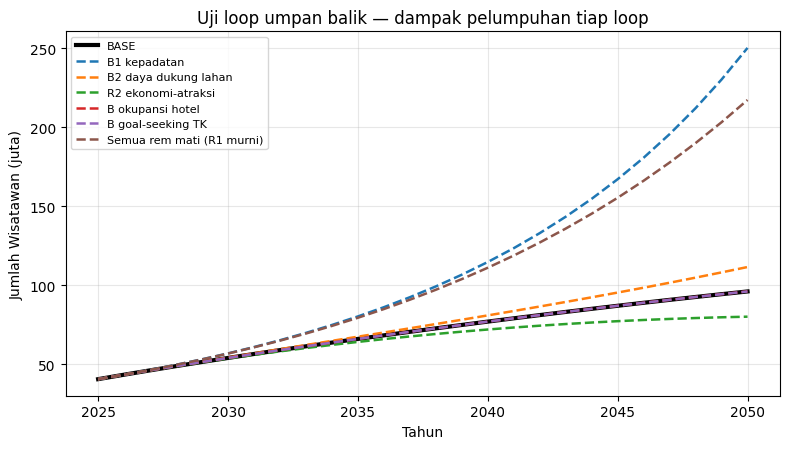

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[01] Uji Struktural/Uji Kekekalan Materi dan Uji Loop/hasil_uji_loop_dan_kekekalan.xlsx


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for nama, r in seri_loop.items():
    gaya = dict(lw=3, color="black") if nama.startswith("BASE") else dict(lw=1.8, ls="--")
    ax.plot(r.index, r["Jumlah Wisatawan"]/1e6, label=nama, **gaya)
ax.set_xlabel("Tahun"); ax.set_ylabel("Jumlah Wisatawan (juta)")
ax.set_title("Uji loop umpan balik — dampak pelumpuhan tiap loop")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FOLDER / "uji_loop_wisatawan.png", dpi=150); plt.show()

berkas = FOLDER / "hasil_uji_loop_dan_kekekalan.xlsx"
with pd.ExcelWriter(berkas) as w:
    kekekalan.round(8).to_excel(w, sheet_name="Kekekalan Materi", index=False)
    loop.round(4).to_excel(w, sheet_name="Uji Loop Umpan Balik", index=False)
    nilai_2050.round(4).to_excel(w, sheet_name="Nilai 2050 per Loop")
    selisih_2050.round(4).to_excel(w, sheet_name="Selisih Persen per Loop")
    ringkas_dampak.round(4).to_excel(w, sheet_name="Ringkasan Dampak Loop")
    BASE.round(4).to_excel(w, sheet_name="BASE seri")
    for nama, r in seri_loop.items():
        if nama != "BASE":
            r.round(4).to_excel(w, sheet_name=f"Loop {nama}"[:31])
print("Tersimpan:", berkas)

## Angka untuk pencocokan

**Kekekalan materi:** kelima stok selisih 0,0 untuk seluruh 2025–2049.
Contoh Hotel: 2.291 + 158,17937 − 114,55000 = 2.334,62937 = simulasi 2026.

**Uji loop umpan balik:**

| Loop dilumpuhkan | JW 2050 (juta) | Selisih vs BASE | Daya Tarik 2050 |
|---|---|---|---|
| BASE | 96,197 | — | 0,813 |
| B1 kepadatan | 250,320 | +160,2% | 1,070 |
| B2 daya dukung lahan | 111,658 | +16,1% | 0,863 |
| R2 ekonomi–atraksi | 80,238 | −16,6% | 0,764 |
| B okupansi hotel | 96,230 | +0,03% (Hotel 4.867) | 0,813 |
| B goal-seeking TK | 96,197 | 0,00% (TK 364,99 ribu) | 0,813 |
| Semua rem mati (R1 murni) | 217,365 | +126,0% | 1,000 |

Peringkat kekuatan loop: **B1 kepadatan > B2 lahan ≈ R2 ekonomi–atraksi > B okupansi hotel > B tenaga kerja**.